In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Setting seed for reproducability
from sklearn import preprocessing
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score

# Torch stuff
import torch
import torch.nn as nn
import random
from torch.utils.data import TensorDataset, DataLoader, random_split

In [2]:
# Import all stages of the data for FD001

# Feature Engineering (Default using Piecewise 150)
fe2_lv1_fd001_train = pd.read_csv("../../data/processed-nasa-data/feature_engineering_2/low_variance_1/train_fd001_low_variance_1_125.csv")
fe2_lv1_fd001_test = pd.read_csv("../../data/processed-nasa-data/feature_engineering_2/low_variance_1/test_fd001_low_variance_1_125.csv")

In [3]:
# Prepare the data at the sequence length
sequence_lengths = [30,50,70]

# Pick which dataset pair(s) you want to prepare
dataset_pairs = {
    "fe2_lv1": (fe2_lv1_fd001_train, fe2_lv1_fd001_test),
}

def gen_sequence(id_df, seq_length, seq_cols):
    data_array = id_df[seq_cols].values
    n = data_array.shape[0]
    for start, stop in zip(range(0, n - seq_length), range(seq_length, n)):
        yield data_array[start:stop, :]

def gen_labels(id_df, seq_length, label_col):
    data_array = id_df[label_col].values
    return data_array[seq_length:]

def build_sequence_data(train_df, test_df, seq_length, label_col="RUL"):
    # Features: everything except id/cycle/label
    seq_cols = [c for c in train_df.columns if c not in ["id", "cycle", label_col]]

    # Train windows + labels
    X_train = np.concatenate([
        np.array(list(gen_sequence(train_df[train_df["id"] == eid], seq_length, seq_cols)))
        for eid in train_df["id"].unique()
        if len(train_df[train_df["id"] == eid]) > seq_length
    ]).astype(np.float32)

    y_train = np.concatenate([
        gen_labels(train_df[train_df["id"] == eid], seq_length, [label_col])
        for eid in train_df["id"].unique()
        if len(train_df[train_df["id"] == eid]) > seq_length
    ]).astype(np.float32).reshape(-1, 1)

    # Test: last window per engine + last label
    X_test = np.array([
        test_df[test_df["id"] == eid][seq_cols].values[-seq_length:]
        for eid in test_df["id"].unique()
        if len(test_df[test_df["id"] == eid]) >= seq_length
    ]).astype(np.float32)

    mask = [len(test_df[test_df["id"] == eid]) >= seq_length for eid in test_df["id"].unique()]
    y_test = test_df.groupby("id")[label_col].nth(-1)[mask].values.astype(np.float32).reshape(-1, 1)

    return seq_cols, X_train, y_train, X_test, y_test

prepared_data = {}

for seq_len in sequence_lengths:
    for name, (tr_df, te_df) in dataset_pairs.items():
        seq_cols, X_train, y_train, X_test, y_test = build_sequence_data(tr_df, te_df, seq_len, label_col="RUL")

        prepared_data[(name, seq_len)] = {
            "seq_cols": seq_cols,
            "X_train": X_train,
            "y_train": y_train,
            "X_test": X_test,
            "y_test": y_test,
            "X_train_t": torch.tensor(X_train, dtype=torch.float32),
            "y_train_t": torch.tensor(y_train, dtype=torch.float32),
            "X_test_t": torch.tensor(X_test, dtype=torch.float32),
            "y_test_t": torch.tensor(y_test, dtype=torch.float32),
        }

        print(f"{name} | seq_len={seq_len}")
        print("  X_train:", X_train.shape, "y_train:", y_train.shape)
        print("  X_test :", X_test.shape,  "y_test :", y_test.shape)

fe2_lv1 | seq_len=30
  X_train: (17631, 30, 17) y_train: (17631, 1)
  X_test : (100, 30, 17) y_test : (100, 1)
fe2_lv1 | seq_len=50
  X_train: (15631, 50, 17) y_train: (15631, 1)
  X_test : (93, 50, 17) y_test : (93, 1)
fe2_lv1 | seq_len=70
  X_train: (13631, 70, 17) y_train: (13631, 1)
  X_test : (86, 70, 17) y_test : (86, 1)


In [4]:
# Define model architecture (2-layer GRU regression)
class BasicGRURUL(nn.Module):
    def __init__(self, input_size, gru1_hidden=100, gru2_hidden=50, dropout=0.2):
        super().__init__()
        self.gru1 = nn.GRU(
            input_size=input_size,
            hidden_size=gru1_hidden,
            batch_first=True,
        )
        self.dropout1 = nn.Dropout(dropout)

        self.gru2 = nn.GRU(
            input_size=gru1_hidden,
            hidden_size=gru2_hidden,
            batch_first=True,
        )
        self.dropout2 = nn.Dropout(dropout)

        self.fc = nn.Linear(gru2_hidden, 1)

    def forward(self, x):
        out, _ = self.gru1(x)
        out = self.dropout1(out)

        out, _ = self.gru2(out)
        out = self.dropout2(out)

        last = out[:, -1, :]
        pred = self.fc(last)
        return pred


# RMSE loss for regression
class RMSELoss(nn.Module):
    def __init__(self, eps=1e-8):
        super().__init__()
        self.mse = nn.MSELoss()
        self.eps = eps

    def forward(self, y_pred, y_true):
        return torch.sqrt(self.mse(y_pred, y_true) + self.eps)

In [ ]:
from pathlib import Path

def train_and_evaluate_gru_all_datasets(
    prepared_data,
    sequence_lengths=[30],
    epochs=30,
    batch_size=128,
    lr=None,
    learning_rates=(1e-3),
    gru1_hidden=100,
    gru2_hidden=50,
    dropout=0.2,
    val_ratio=0.2,
    patience=5,
    seed=1234,
    export_dir="./saved_models/gru",
):
    """
    Train one BasicGRURUL per dataset/sequence-length and report train/val/test RMSE.
    Optimization criterion is MSE; reported metrics are RMSE.
    Also exports each trained model checkpoint to disk.
    Returns:
        results_df: summary table (includes exported model path)
        trained_models: dict[(dataset_name, seq_len, lr)] -> trained model
        histories: dict[(dataset_name, seq_len, lr)] -> {'train_rmse': [...], 'val_rmse': [...]}
    """

    if lr is not None:
        learning_rates = (float(lr),)
    else:
        learning_rates = tuple(float(v) for v in learning_rates)

    export_path = Path(export_dir)
    export_path.mkdir(parents=True, exist_ok=True)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    results = []
    trained_models = {}
    histories = {}

    dataset_name_map = {
        "fe2_lv1": "FD001_low_variance_1",
    }

    report_columns = [
        "Dataset",
        "Sequence Length",
        "Learning Rate",
        "Seed",
        "Train RMSE",
        "Val RMSE",
        "Test RMSE",
        "Model Path",
    ]

    for (dataset_name, seq_len), d in prepared_data.items():
        if seq_len not in sequence_lengths:
            continue

        X_train = d["X_train_t"]
        y_train = d["y_train_t"]
        X_test = d["X_test_t"]
        y_test = d["y_test_t"]
        seq_cols = d["seq_cols"]
        dataset_label = dataset_name_map.get(dataset_name, dataset_name)

        for current_lr in learning_rates:
            print(
                f"Training and evaluating {dataset_label} | seq_len={seq_len} | lr={current_lr:.1e} | seed={seed}"
            )

            # Set seeds for reproducibility
            torch.manual_seed(seed)
            np.random.seed(seed)
            random.seed(seed)
            if torch.cuda.is_available():
                torch.cuda.manual_seed_all(seed)

            # Build dataset + split
            dataset = TensorDataset(X_train, y_train)
            val_size = max(1, int(len(dataset) * val_ratio))
            train_size = len(dataset) - val_size

            train_ds, val_ds = random_split(
                dataset,
                [train_size, val_size],
                generator=torch.Generator().manual_seed(seed),
            )

            train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
            val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

            # Fresh model per dataset + learning rate
            model = BasicGRURUL(
                input_size=len(seq_cols),
                gru1_hidden=gru1_hidden,
                gru2_hidden=gru2_hidden,
                dropout=dropout,
            ).to(device)

            # Use MSE for optimization updates
            criterion = nn.MSELoss()
            optimizer = torch.optim.Adam(model.parameters(), lr=current_lr)

            best_val_mse = float("inf")
            best_state = None
            patience_count = 0
            train_curve = []
            val_curve = []

            # Train
            for epoch in range(1, epochs + 1):
                model.train()
                train_loss_sum = 0.0

                for xb, yb in train_loader:
                    xb, yb = xb.to(device), yb.to(device)

                    optimizer.zero_grad()
                    pred = model(xb)
                    loss = criterion(pred, yb)
                    loss.backward()
                    optimizer.step()

                    train_loss_sum += loss.item() * xb.size(0)

                train_mse = train_loss_sum / len(train_loader.dataset)
                train_rmse = float(np.sqrt(train_mse))

                model.eval()
                val_loss_sum = 0.0
                with torch.no_grad():
                    for xb, yb in val_loader:
                        xb, yb = xb.to(device), yb.to(device)
                        pred = model(xb)
                        loss = criterion(pred, yb)
                        val_loss_sum += loss.item() * xb.size(0)

                val_mse = val_loss_sum / len(val_loader.dataset)
                val_rmse = float(np.sqrt(val_mse))
                train_curve.append(train_rmse)
                val_curve.append(val_rmse)

                if val_mse < best_val_mse:
                    best_val_mse = val_mse
                    best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                    patience_count = 0
                else:
                    patience_count += 1
                    if patience_count >= patience:
                        break

            # Restore best
            if best_state is not None:
                model.load_state_dict(best_state)

            # Final test RMSE evaluation
            model.eval()
            with torch.no_grad():
                test_pred = model(X_test.to(device))
                test_mse = criterion(test_pred, y_test.to(device)).item()
                test_rmse = float(np.sqrt(test_mse))

            # Also compute final train RMSE (full train tensor)
            with torch.no_grad():
                train_pred_full = model(X_train.to(device))
                train_mse_full = criterion(train_pred_full, y_train.to(device)).item()
                train_rmse_full = float(np.sqrt(train_mse_full))

            best_val_rmse = float(np.sqrt(best_val_mse))

            lr_tag = f"{current_lr:.0e}".replace("+", "")
            model_filename = f"gru_{dataset_name}_seq{seq_len}_lr{lr_tag}_seed{seed}.pt"
            model_path = export_path / model_filename
            checkpoint = {
                "state_dict": model.state_dict(),
                "dataset_name": dataset_name,
                "dataset_label": dataset_label,
                "seq_len": int(seq_len),
                "learning_rate": float(current_lr),
                "seed": int(seed),
                "input_size": int(len(seq_cols)),
                "gru1_hidden": int(gru1_hidden),
                "gru2_hidden": int(gru2_hidden),
                "dropout": float(dropout),
                "best_val_rmse": float(best_val_rmse),
                "test_rmse": float(test_rmse),
                "feature_columns": list(seq_cols),
            }
            torch.save(checkpoint, model_path)
            print(f"Saved model checkpoint to: {model_path}")

            results.append({
                "Dataset": dataset_label,
                "Sequence Length": int(seq_len),
                "Learning Rate": float(current_lr),
                "Seed": int(seed),
                "Train RMSE": float(train_rmse_full),
                "Val RMSE": float(best_val_rmse),
                "Test RMSE": float(test_rmse),
                "Model Path": str(model_path),
            })

            trained_models[(dataset_name, seq_len, float(current_lr))] = model
            histories[(dataset_name, seq_len, float(current_lr))] = {
                "train_rmse": train_curve,
                "val_rmse": val_curve,
            }

    results_df = pd.DataFrame(results, columns=report_columns).sort_values(
        ["Dataset", "Sequence Length", "Learning Rate", "Seed"]
    ).reset_index(drop=True)

    print("Dataset\tSeq Len\tLR\tSeed\tTrain RMSE\tVal RMSE\tTest RMSE")
    for _, row in results_df.iterrows():
        print(
            f"{row['Dataset']}\t{int(row['Sequence Length'])}\t{row['Learning Rate']:.1e}\t{int(row['Seed'])}\t{row['Train RMSE']:.4f}\t{row['Val RMSE']:.4f}\t{row['Test RMSE']:.4f}"
        )

    return results_df, trained_models, histories

In [15]:
results_df, trained_models, histories = train_and_evaluate_gru_all_datasets(
    prepared_data=prepared_data,
    sequence_lengths=[30],
    epochs=50,
    lr=0.001,
    batch_size=64,
    gru1_hidden=100,
    gru2_hidden=50,
    dropout=0.2,
    patience=5,
    seed=999,
    export_dir="./saved_models/gru_seed_999",
)

display(results_df)

Training and evaluating FD001_low_variance_1 | seq_len=30 | lr=1.0e-03 | seed=999
Saved model checkpoint to: saved_models\gru_seed_999\gru_fe2_lv1_seq30_lr1e-03_seed999.pt
Dataset	Seq Len	LR	Seed	Train RMSE	Val RMSE	Test RMSE
FD001_low_variance_1	30	1.0e-03	999	12.6590	12.6701	13.2656


,Dataset,Sequence Length,Learning Rate,Seed,Train RMSE,Val RMSE,Test RMSE,Model Path
0,FD001_low_variance_1,30,0.001,999,12.658996,12.670133,13.265557,saved_models\gru_seed_999\gru_fe2_lv1_seq30_lr...


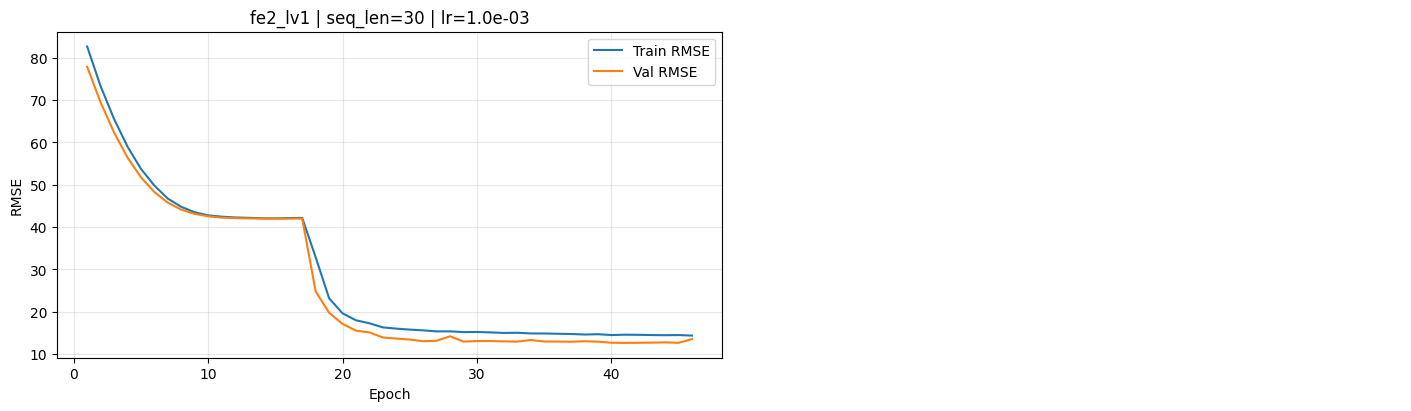

In [7]:
# Plot training curves (train/val RMSE) for each dataset + learning rate
n = len(histories)
ncols = 2
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows), constrained_layout=True)
axes = np.array(axes).reshape(-1)

for i, ((dataset_name, seq_len, lr), h) in enumerate(histories.items()):
    ax = axes[i]
    epochs_axis = np.arange(1, len(h["train_rmse"]) + 1)
    ax.plot(epochs_axis, h["train_rmse"], label="Train RMSE")
    ax.plot(epochs_axis, h["val_rmse"], label="Val RMSE")
    ax.set_title(f"{dataset_name} | seq_len={seq_len} | lr={lr:.1e}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("RMSE")
    ax.grid(alpha=0.3)
    ax.legend()

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.show()